In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("/content/Sample - Superstore.csv", encoding='latin1')

In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,06-12-2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4557 entries, 0 to 4556
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         4557 non-null   int64  
 1   Order ID       4557 non-null   object 
 2   Order Date     4557 non-null   object 
 3   Ship Date      4557 non-null   object 
 4   Ship Mode      4557 non-null   object 
 5   Customer ID    4557 non-null   object 
 6   Customer Name  4557 non-null   object 
 7   Segment        4557 non-null   object 
 8   Country        4557 non-null   object 
 9   City           4557 non-null   object 
 10  State          4557 non-null   object 
 11  Postal Code    4557 non-null   int64  
 12  Region         4557 non-null   object 
 13  Product ID     4557 non-null   object 
 14  Category       4557 non-null   object 
 15  Sub-Category   4557 non-null   object 
 16  Product Name   4557 non-null   object 
 17  Sales          4557 non-null   float64
 18  Quantity

Category with highest quantity

<Axes: xlabel='Category', ylabel='Quantity'>

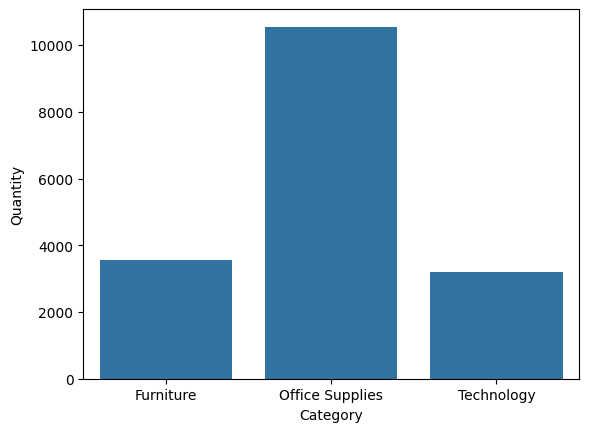

In [ ]:
category_quntity=df.groupby('Category')['Quantity'].sum().reset_index()
sns.barplot(x='Category', y='Quantity', data=category_quntity)

Office Supplies Category is the dominant category, contributing the largest share of the total quantity. Its indicates the highest demand the compared to the other category

Which segment buys most?

<Axes: xlabel='Segment', ylabel='Sales'>

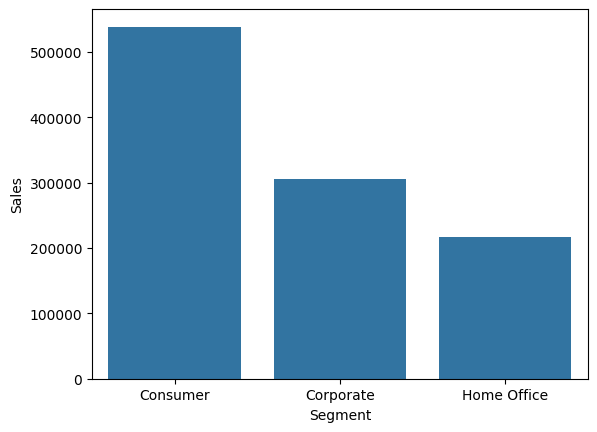

In [ ]:
sales_sagment=df.groupby("Segment")['Sales'].sum().reset_index()
sns.barplot(x='Segment', y='Sales', data=sales_sagment)


The graph clearly shows that the **Consumer** segment has the highest purchase volume, followed by **Corporate** and **Home** **Office**. This indicates that consumer customers play the biggest role in driving sales.

Which category gives highest sales?

<Axes: xlabel='Category', ylabel='Sales'>

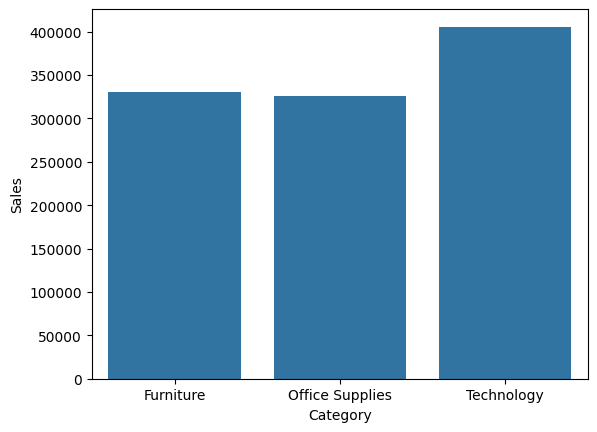

In [ ]:
product_sales=df.groupby('Category')['Sales'].sum().reset_index()
sns.barplot(x='Category', y='Sales', data=product_sales)

This graph clearly shows that **Technology** category has generated the highest sales among all caategories.

Which customer segment is most profitable?

In [ ]:
df.groupby('Segment')['Profit'].sum()

,Profit
Segment,
Consumer,64078.9946
Corporate,31435.3484
Home Office,24031.7186


Total Discount on each category

<Axes: xlabel='Category', ylabel='Discount'>

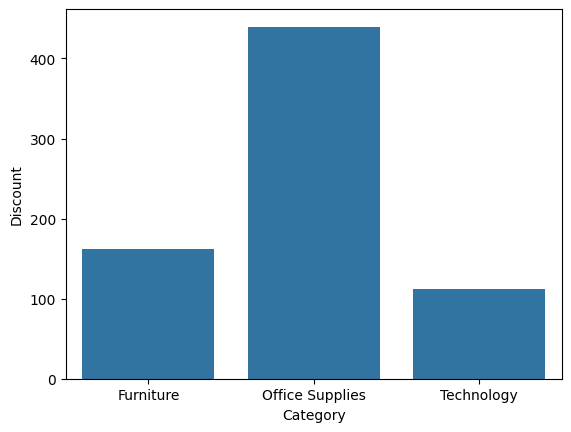

In [ ]:
category_discount=df.groupby('Category')['Discount'].sum().reset_index()
sns.barplot(x='Category', y='Discount', data=category_discount)

**Office** **Supplies** has highest discount on them followed by **Furniture** and **Technology** category.

Which category gives highest profit?

<Axes: xlabel='Category', ylabel='Profit'>

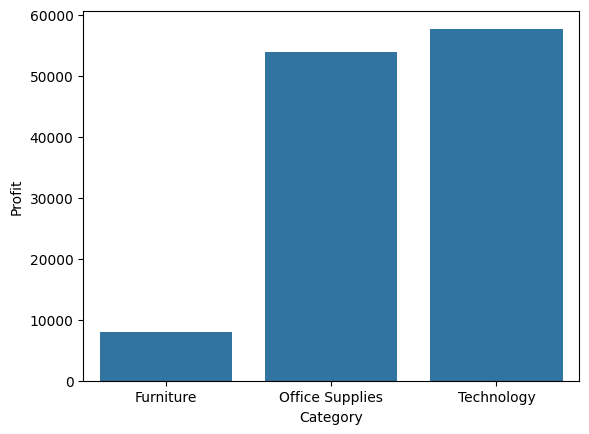

In [ ]:
category_profit=df.groupby('Category')['Profit'].sum().reset_index()
sns.barplot(x='Category', y='Profit', data=category_profit)

Conclusion
Office Supplies received the highest discounts but still made good profit.
Technology generated the highest profit with comparatively lower discounts.
Furniture made lower profit even with lower discounts.

Which region has highest profit margin?

In [ ]:
df.groupby('Region')['Profit'].sum().reset_index()
#Total profit generated by each region

,Region,Profit
0,Central,14753.8431
1,East,40471.4019
2,South,21442.1460
3,West,42878.6706


Are discounts reducing profit?

<Axes: xlabel='Discount', ylabel='Profit'>

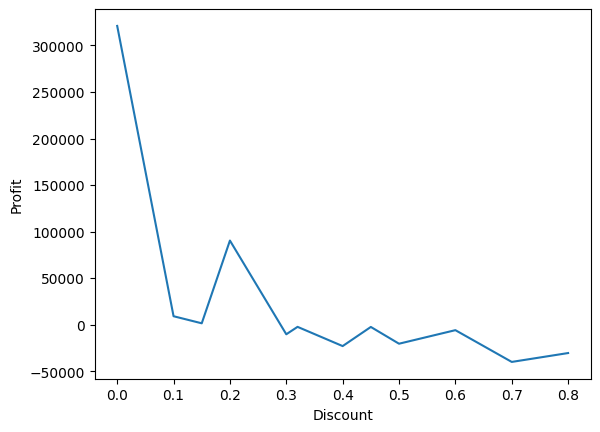

In [ ]:
dis_profit=df.groupby('Discount')['Profit'].sum().reset_index()
sns.lineplot(x='Discount', y='Profit', data=dis_profit)

From the above graph, it is clear that as discount increases profit deecreases. We can say that discount and Profit show negative correlation

In [ ]:
#Sub-categories in each category
df.groupby("Category")['Sub-Category'].nunique()

,Sub-Category
Category,
Furniture,4
Office Supplies,9
Technology,4


Which region is strongest?

<Axes: xlabel='Region', ylabel='Sales'>

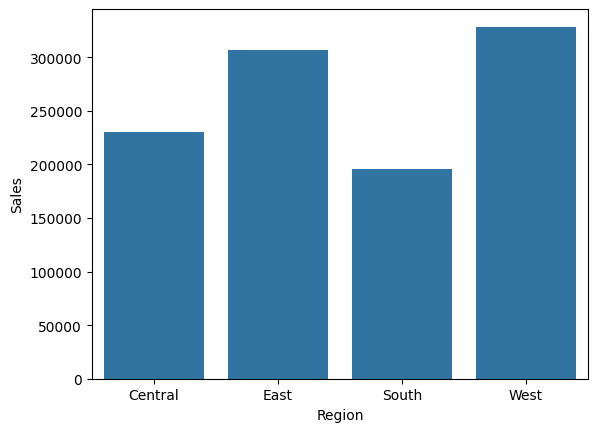

In [ ]:
region_sales=df.groupby("Region")['Sales'].sum().reset_index()
sns.barplot(x='Region', y='Sales', data=region_sales)

The graph clearly shows that highest sales are made by the **West** region and lowest sales are made by the **South** region among all regions.

Which shipping mode is fastest/profitable?

<Axes: xlabel='Ship Mode', ylabel='Profit'>

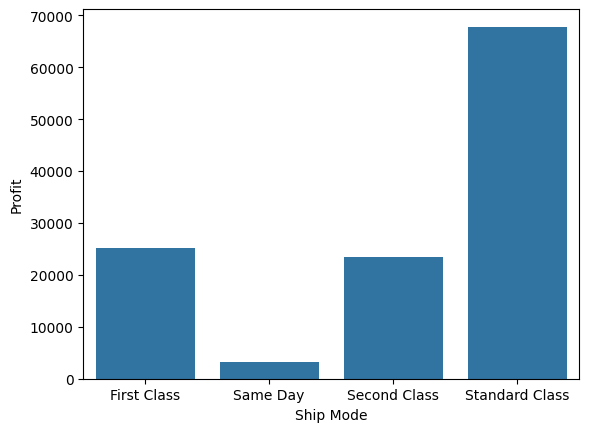

In [ ]:
ship_mode=df.groupby('Ship Mode')['Profit'].sum().reset_index()
sns.barplot(x='Ship Mode', y='Profit', data=ship_mode)

The most profitable shipping mode is Standard Class as we can see from above graph

Which segment are loss-making?

<Axes: xlabel='Segment', ylabel='Profit'>

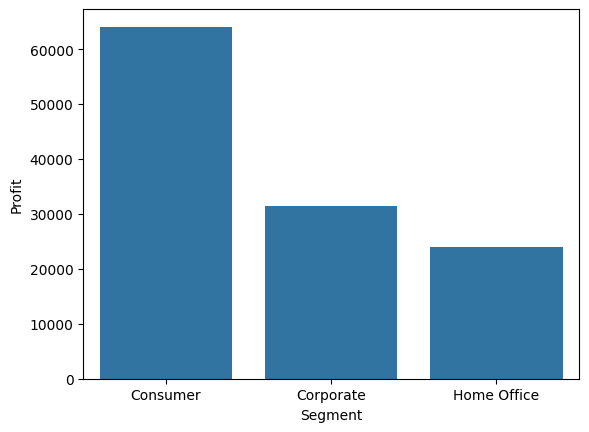

In [ ]:
segment_profit=df.groupby('Segment')['Profit'].sum().reset_index()
sns.barplot(x='Segment', y='Profit', data=segment_profit)

The graph clearly shows that the loss-making segment is Home office and most of the profit generated by Consumer Segment

Which sub-category performs best?

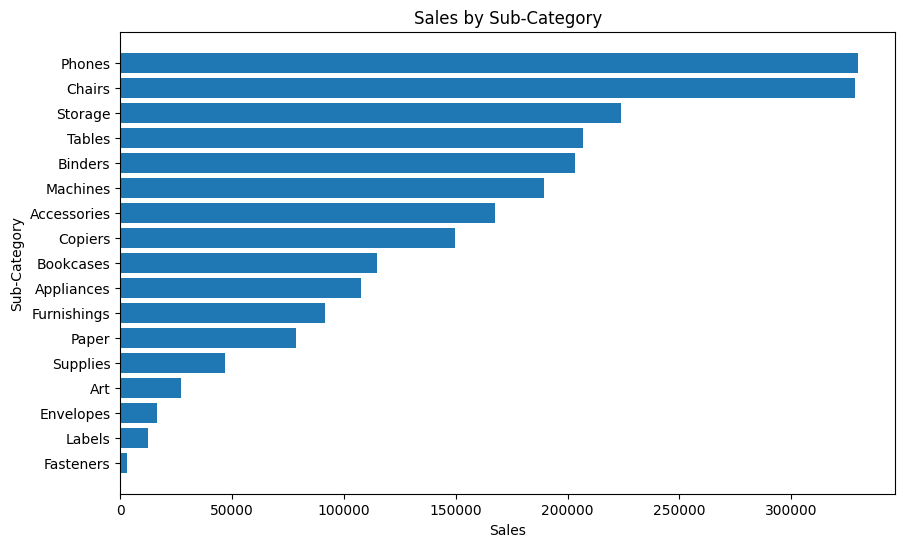

In [ ]:
sales_subcategory=df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=True)
plt.figure(figsize=(10,6))
plt.barh(sales_subcategory.index, sales_subcategory.values)
plt.xlabel('Sales')
plt.ylabel('Sub-Category')
plt.title('Sales by Sub-Category')
plt.show()

From the above graph it is clear that highest sales are made by **Phone** and the lowest sales are made by **Fasteners** among all sub-categories.

Highest Sales in which month?

In [ ]:
df['Order Date']=pd.to_datetime(df['Order Date'], format='mixed')
df['Month']=df['Order Date'].dt.month

df.groupby('Month')['Sales'].sum().sort_values(ascending=False)

,Sales
Month,
11,164472.2899
9,149094.3357
12,141996.3365
3,95229.7128
10,87884.5145
7,83123.6210
8,77328.6383
4,75885.8521
6,67943.2911


Monthly Sales Trend

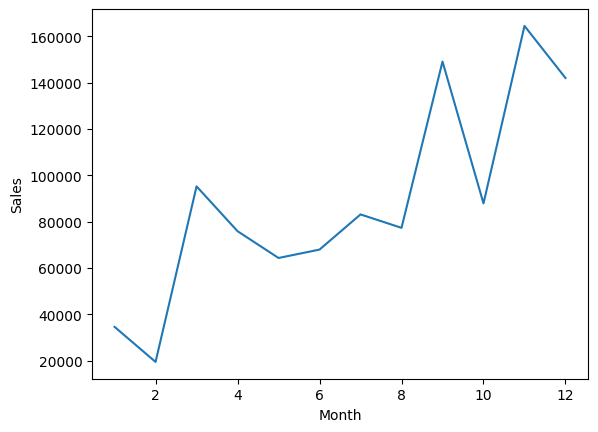

In [ ]:
monthly_sales = df.groupby("Month")["Sales"].sum().reset_index()

sns.lineplot(x="Month", y="Sales", data=monthly_sales)

plt.show()

The graph clearly shows the monthly sales trend and the highest sales are generated by 11th month

Key Findings


* Technology category generated the highest sales.  

* The West region recorded the highest sales, while the South region had the lowest.

* Standard Class was the most profitable shipping mode.
* Consumer customers contributed the highest number of purchases.





  



Based on these findings, the company

* Improve Marketing efforts or Customer services in lowest-selling region.


* Ensure that high-demand products are consistently kept in stock to avoid missed sales opportunities.


* Offer discounts strategically, as the analysis suggest it will not affect the profit margin of products.


* Standard Class is both the most profitable and most frequently used shipping mode. The company can focus on improving and promoting this shipping option to enhance customer satisfaction and profitability.


*   As we seen in the analysis the lowest selling segment is Home Office, it may be due to limited product range, less target audience in this segment or less targeted marketing then other segments.







